In [5]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import import_ipynb
import preprocessing

In [6]:
X_train = pd.read_csv("X_train_scaled.csv")
X_test  = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv")["Loan Status"]
y_test  = pd.read_csv("y_test.csv")["Loan Status"]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (71828, 27) X_test: (17958, 27)
y_train: (71828,) y_test: (17958,)


In [ ]:
# TO DO: Initialize the random forest classification model

rfc = RandomForestClassifier(n_estimators=200, # num of trees
                             max_depth=None, # tree depth
                             min_samples_split=2, # min samples to split a node
                             random_state=16,
                             class_weight='balanced'
                             )

    
# TO DO: fit the model

rfc.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
#TO DO: use predict_proba to get probabilities and make predictions
y_prob = rfc.predict_proba(X_test)[:,1]
y_pred = rfc.predict(X_test)

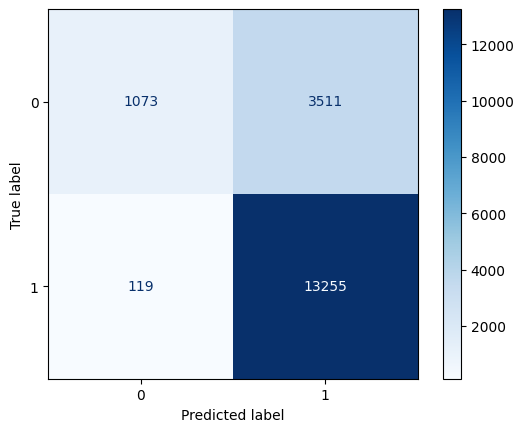

In [37]:
#TO DO: Visualize confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [32]:
#TO DO: Calculate accuracy using sklearn metrics
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

conf_matrix = metrics.confusion_matrix(y_test, y_pred)
num = conf_matrix[0][0]+conf_matrix[1][1]
denom = conf_matrix[0][0]+conf_matrix[0][1]+conf_matrix[1][0]+conf_matrix[1][1]
print(num/denom)

0.7978616772469095
0.7978616772469095


In [33]:
#TO DO: Calculate precision using sklearn metrics
precision = metrics.precision_score(y_test,y_pred)
print(precision)

conf_matrix = metrics.confusion_matrix(y_test , y_pred)
num = conf_matrix[1][1]
denom = conf_matrix[1][1]+conf_matrix[0][1]
print(num/denom)

0.7905880949540737
0.7905880949540737


In [34]:
#TO DO: Calculate recall using sklearn metrics
recall = metrics.recall_score(y_test, y_pred)
print(recall)

num = conf_matrix[1][1]
denom = conf_matrix[1][1]+conf_matrix[1][0]
print(num/denom)

0.9911021384776432
0.9911021384776432


In [35]:
#TO DO: Calculate F1 score using sklearn metrics
f1_score = metrics.f1_score(y_test,y_pred)
print(f1_score)

f1 = 2*precision*recall/(precision+recall)
print(f1)

0.8795620437956204
0.8795620437956204


In [36]:
#TO DO: Calculate specificity using confusion matrix
num = conf_matrix[0][0]
denom = conf_matrix[0][0]+conf_matrix[0][1]
print(num/(denom))

0.23407504363001747


AUROC:  0.7566861354283049


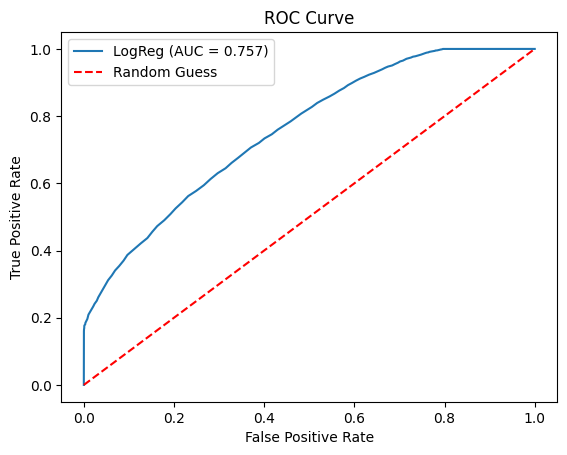

In [39]:
from sklearn.metrics import roc_auc_score, roc_curve

# TO DO: Calculate AUROC

auroc = metrics.roc_auc_score(y_test,y_prob)
print("AUROC: " , auroc)

# TO DO: Plot ROC curve
# TO DO: Plot ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)
plt.plot(fpr,tpr,label=f"LogReg (AUC = {auroc:.3f})")
plt.plot([0,1], [0,1],'r--', label= "Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()